# Plots
Loads all scenario results and produces all figures.
**Run all scenario notebooks first.**

## Load all scenario results

In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from model_functions import load_remind_data
from model_functions import compare_remind_h2

data_folder = Path.cwd().parent / 'data' / 'processed'

scenario_files = {
    'Baseline':   '00_baseline.pkl',
    'Full transition':       '01_best.pkl',
    'Delayed transition':      '02_worst.pkl',
    'Circular Economy':      '03_socio.pkl',
    'Technology':     '04_techno.pkl',
}

scenarios = {}
for name, fname in scenario_files.items():
    with open(data_folder / fname, 'rb') as f:
        scenarios[name] = pickle.load(f)
    print(f'Loaded: {name}')

# Shared
baseline   = scenarios['Baseline']
years      = baseline['years']
plot_years = baseline['plot_years']

# Color palette
sc_colors = {
    'Baseline': '#4a4a4a',
    'Full transition':     '#1a5c3a',
    'Delayed transition':    '#8B1A1A',
    'Circular Economy':    '#1B4F8A',
    'Technology':   '#0D6B5E',
}

wsa_years  = list(baseline['wsa_production'].keys())
wsa_values = [v * 1e6 for v in baseline['wsa_production'].values()]

file_paths = {
    'SSP2 Current policies':  r'C:\Users\idapo\master_thesis\master-1\electrolysers\data\raw\future\REMIND_generic_C_SMIPv08-M-SSP2-NPi2025-def-rem-6.mif',
    'SSP2 Carbon price ~400': r'C:\Users\idapo\master_thesis\master-1\electrolysers\data\raw\future\REMIND_generic_C_SMIPv08-L-SSP2-PkPrice400-def-rem-6.mif',
    'SSP1 Ambitious':         r'C:\Users\idapo\master_thesis\master-1\electrolysers\data\raw\future\REMIND_generic_C_SMIPv08-VLLO-SSP1-PkPrice500-def-rem-6.mif',
}

remind_colors = {
    'SSP2 Current policies':  '#8B1A1A',
    'SSP2 Carbon price ~400': '#cf9140',
    'SSP1 Ambitious':         '#1a5c3a',
}

remind_data   = load_remind_data(file_paths)
remind_years  = list(remind_data.values())[0]['years']
h2_interp     = compare_remind_h2(scenarios, remind_data)

Loaded: Baseline
Loaded: Full transition
Loaded: Delayed transition
Loaded: Circular Economy
Loaded: Technology
Loaded: SSP2 Current policies  |  Green H2 2050: 50.9 Mt  |  Renew elec 2050: 53562 TWh  |  Electrolysis elec 2050: 2751 TWh
Loaded: SSP2 Carbon price ~400  |  Green H2 2050: 109.7 Mt  |  Renew elec 2050: 64298 TWh  |  Electrolysis elec 2050: 5925 TWh
Loaded: SSP1 Ambitious  |  Green H2 2050: 301.7 Mt  |  Renew elec 2050: 88673 TWh  |  Electrolysis elec 2050: 16304 TWh


## 1. Total in-use steel stock — baseline

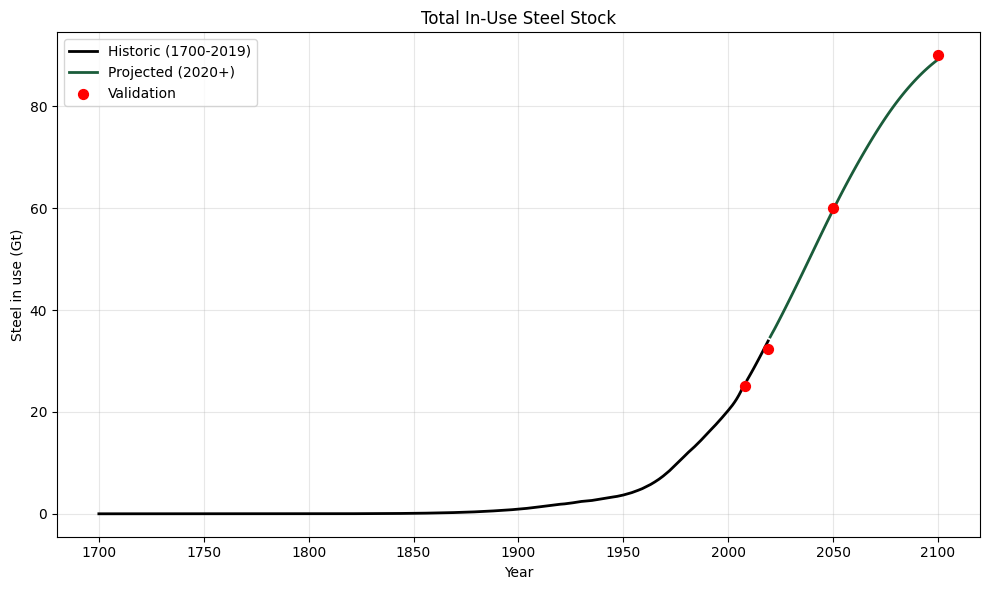

In [2]:
fig, ax = plt.subplots(figsize=(10, 6))
stock_df = baseline['stock_df']
hist   = stock_df[stock_df['type']=='historic']
recent = stock_df[stock_df['type']=='recent']
pred   = stock_df[stock_df['type']=='predicted']
ax.plot(hist['year'],   hist['total_stock']/1e9, color='black',   linewidth=2,   label='Historic (1700-2019)')
ax.plot(recent['year'], recent['total_stock']/1e9, color='black', linewidth=2)
ax.plot(pred['year'],   pred['total_stock']/1e9,  color='#1a5c3a', linewidth=2, label='Projected (2020+)')
ax.scatter([2008, 2019, 2050, 2100], [25, 32.3, 60, 90], color='red', zorder=5, s=50, label='Validation')
ax.set_xlabel('Year'); ax.set_ylabel('Steel in use (Gt)')
ax.set_title('Total In-Use Steel Stock')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# Save plot to vizualization folder
viz_folder = Path.cwd().parent / 'visualizations'
viz_folder.mkdir(exist_ok=True)
#fig.savefig(viz_folder / 'steel_stock_projection.png', dpi=300)

## 2. Total steel stock — all scenarios

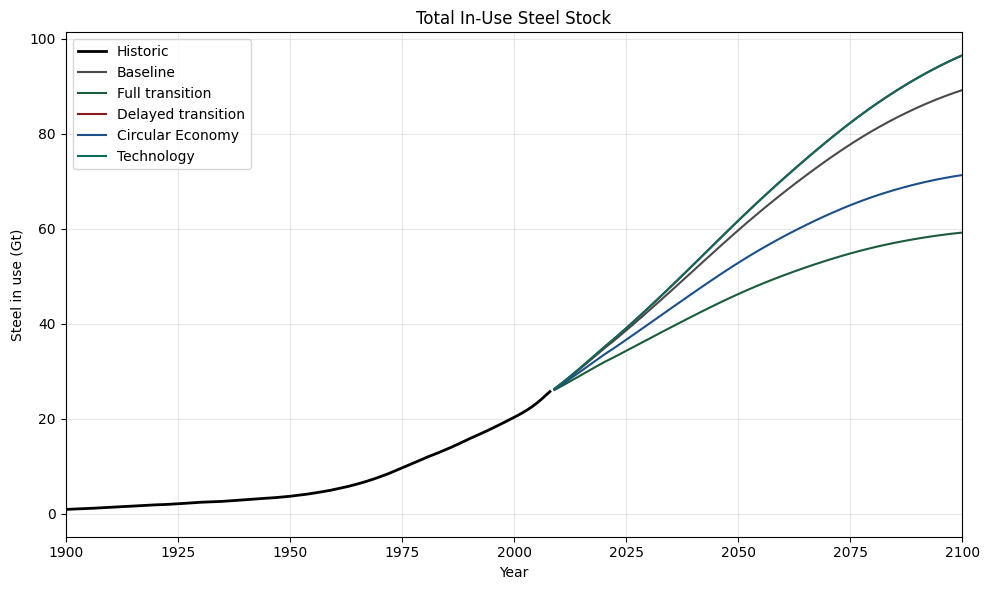

In [3]:
fig, ax = plt.subplots(figsize=(10, 6))
for name, sc in scenarios.items():
    df   = sc['stock_df']
    pred = df[df['type'].isin(['recent','predicted'])]
    hist = df[df['type']=='historic']
    if name == 'Baseline':
        ax.plot(hist['year'], hist['total_stock']/1e9, color='black', linewidth=2, label='Historic')
    ax.plot(pred['year'], pred['total_stock']/1e9, color=sc_colors[name], linewidth=1.5, label=name)
#ax.scatter([2008,2019,2050,2100],[25,32.3,60,90],color='red',zorder=5,s=50,label='Validation')
ax.set_xlabel('Year'); ax.set_ylabel('Steel in use (Gt)')
ax.set_title('Total In-Use Steel Stock')
ax.set_xlim(1900, 2100)
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# Save plot to vizualization folder
#fig.savefig(viz_folder / 'steel_stock_projection_scenarios.png', dpi=300)

## 3. Total crude steel needed vs WSA — baseline

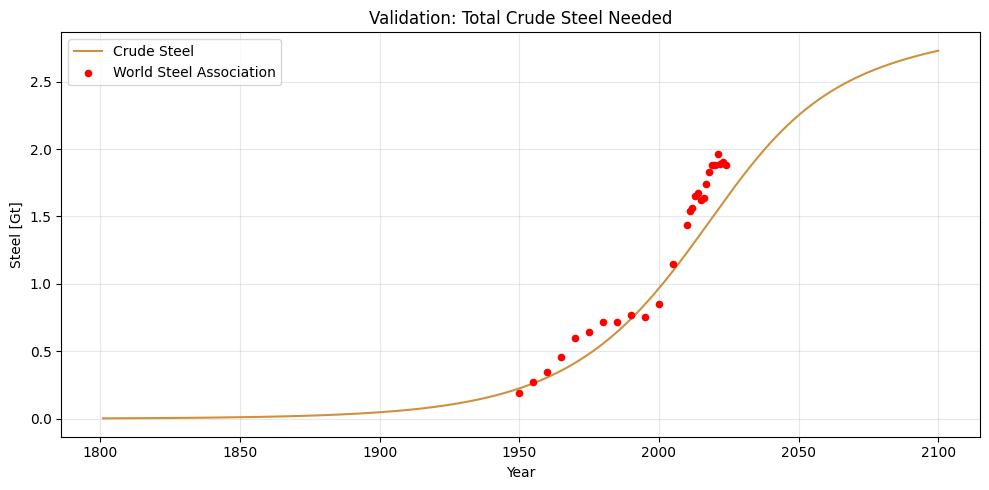

In [4]:
results = baseline['results']
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(results['Year'], results['total_steel_needed']/1e9, label='Crude Steel', color='#cf9140')
ax.scatter(wsa_years, [v/1e9 for v in wsa_values], color='red', s=20, zorder=5, label='World Steel Association')
ax.set_xlabel('Year'); ax.set_ylabel('Steel [Gt]')
ax.set_title('Validation: Total Crude Steel Needed')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# Save plot to vizualization folder
#fig.savefig(viz_folder / 'steel_needed_vs_wsa.png', dpi=300)

## 4. Steel supply transition — baseline

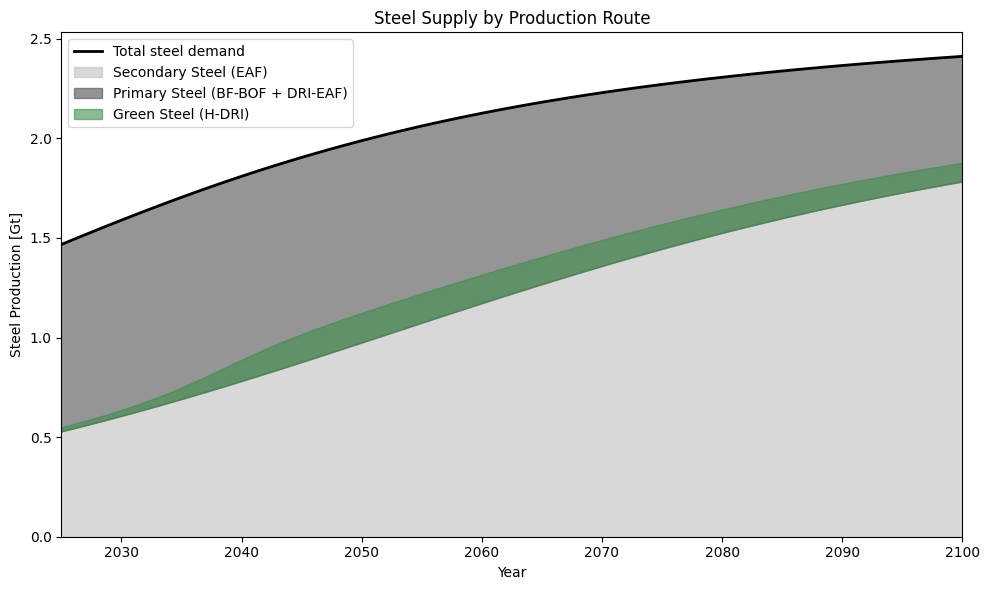

In [5]:
eaf  = baseline['future']['scrap_supply'].values / 1e9
bf   = baseline['production']['BF Production']  / 1e9
dri  = baseline['production']['DRI Production'] / 1e9
td   = baseline['future']['total_inflow'].values / 1e9

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(plot_years, td,  color='black', linewidth=2.0, label='Total steel demand')
#ax.plot(plot_years, eaf, color='gray',  linewidth=2.5, label='Secondary steel (EAF scrap)')
ax.fill_between(plot_years, 0,   eaf,         color="#C1BEBE", alpha=0.6, label='Secondary Steel (EAF)')
ax.fill_between(plot_years, eaf, eaf+dri+bf,  color="#4f4f4f", alpha=0.6, label='Primary Steel (BF-BOF + DRI-EAF)')
ax.fill_between(plot_years, eaf, eaf+dri,     color='#3f8d4c', alpha=0.6, label='Green Steel (H-DRI)')
ax.set_title('Steel Supply by Production Route')
ax.set_xlabel('Year'); ax.set_ylabel('Steel Production [Gt]')
ax.set_ylim(0); ax.set_xlim(2025, 2100); ax.legend(loc='upper left'); ax.grid(True, alpha=0)
plt.tight_layout(); plt.show()

# Save plot to vizualization folder
#fig.savefig(viz_folder / 'steel_supply_transition.png', dpi=300)

## 5. CO2 emissions — all scenarios

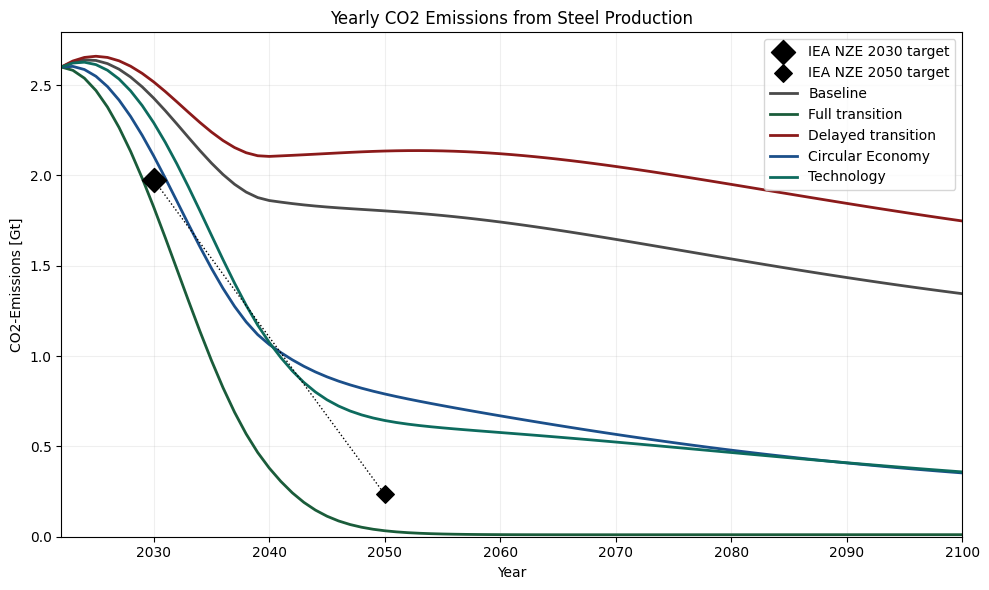

In [42]:
fig, ax = plt.subplots(figsize=(10, 6))

plot_years = baseline['plot_years']

# IEA NZE reference targets
iea_2030_target = 1976 / 1e3
iea_2050_target = 234  / 1e3

# Calibrate all scenarios to IEA 2022 reference (2.6 Gt)
iea_2022_emissions = 2.6
em = {}
for name, sc in scenarios.items():
    model_em   = sc['emissions']['Total Emissions'] / 1e3
    scale_2022 = iea_2022_emissions / model_em[0]
    t          = np.clip((plot_years - 2022) / (2040 - 2022), 0, 1)
    taper      = 0.5 * (1 - np.cos(np.pi * t))   # smooth S-curve 0→1
    em[name]   = model_em * (scale_2022 * (1 - taper) + 1.0 * taper)

ax.scatter([2030], [iea_2030_target], color='black', marker='D',
           s=150, zorder=10, label='IEA NZE 2030 target')
ax.scatter([2050], [iea_2050_target], color='black', marker='D',
           s=80,  zorder=10, label='IEA NZE 2050 target')
ax.plot([2030, 2050], [iea_2030_target, iea_2050_target],
        color='black', linewidth=1, linestyle=':', zorder=9)

#ax.fill_between(plot_years, em['Delayed transition'], em['Full transition'],
#                alpha=0.15, color='gray', label='Scenario range')

#for name in scenarios:
#    if name == 'Baseline':
#        continue
#    ax.fill_between(plot_years, em['Baseline'], em[name],
#                    alpha=0.15, color=sc_colors[name])

for name in scenarios:
    ax.plot(plot_years, em[name],
            color=sc_colors[name], linewidth=2, label=name)

ax.set_title('Yearly CO2 Emissions from Steel Production')
ax.set_xlabel('Year'); ax.set_ylabel('CO2-Emissions [Gt]')
ax.set_ylim(0); ax.set_xlim(2022, 2100)
ax.legend(); ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

# Save plot to vizualization folder
#fig.savefig(viz_folder / 'steel_emissions_scenarios.png', dpi=300)

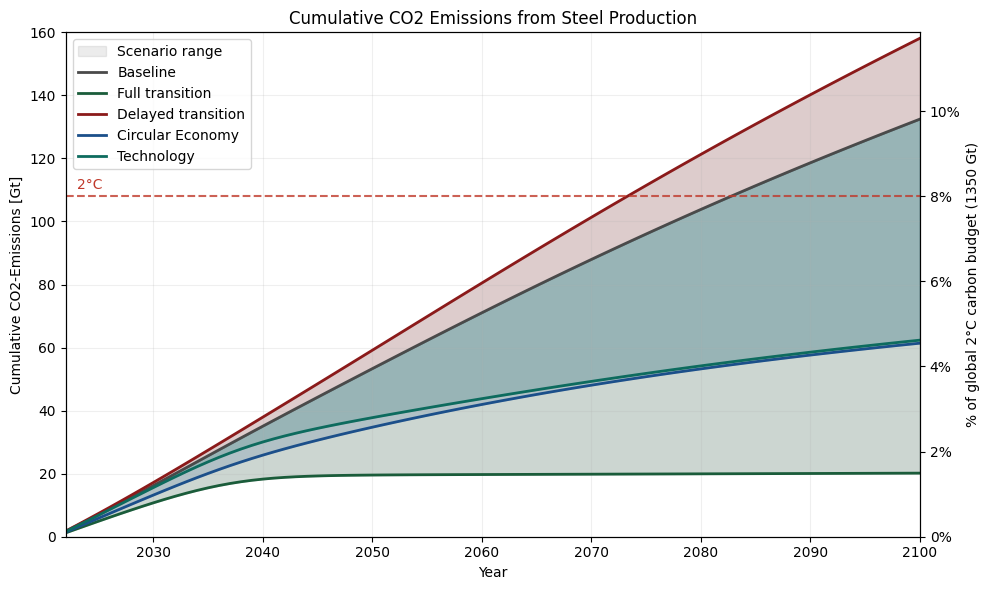

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))

plot_years = baseline['plot_years']

# Cumulative emissions (sum over time)
em_cum = {name: np.cumsum(sc['emissions']['Total Emissions']/1e3) for name, sc in scenarios.items()}

# Fill between worst and best
ax.fill_between(plot_years, em_cum['Delayed transition'], em_cum['Full transition'],
                alpha=0.15, color='gray', label='Scenario range')

# Fill between each scenario and baseline
for name, sc in scenarios.items():
    if name == 'Baseline':
        continue
    ax.fill_between(plot_years, em_cum['Baseline'], em_cum[name],
                    alpha=0.15, color=sc_colors[name])

# Plot lines on top
for name, sc in scenarios.items():
    ax.plot(plot_years, em_cum[name],
            color=sc_colors[name], linewidth=2, label=name)

# Vertical line at 2050
#ax.axvline(2050, color='black', linewidth=1.2, linestyle=':', alpha=0.7)
#ax.text(2051, ax.get_ylim()[1] * 0.97, '2050', fontsize=9, va='top')

# Carbon budget reference lines (steel sector proportional share)
#ax.axhline(37, color='#c0392b', linewidth=1.5, linestyle='--', alpha=0.8)
ax.axhline(108,  color='#c0392b', linewidth=1.5, linestyle='--', alpha=0.8)

# Add text labels for carbon budgets
#ax.text(2023, 37.5 + 1.5, '1.5°C', fontsize=10,
#        color='#c0392b', va='bottom', ha='left')
ax.text(2023, 108  + 1.5, '2°C',   fontsize=10,
        color='#c0392b', va='bottom', ha='left')

ax.set_title('Cumulative CO2 Emissions from Steel Production')
ax.set_xlabel('Year')
ax.set_ylabel('Cumulative CO2-Emissions [Gt]')
ax.set_ylim(0, 160)

budget_total = 1350  # Gt CO2 — IPCC AR6 remaining 1.5°C budget from 2020

ax2 = ax.twinx()
ax2.set_ylim(
    ax.get_ylim()[0] / budget_total * 100,
    ax.get_ylim()[1] / budget_total * 100
)
ax2.set_ylabel('% of global 2°C carbon budget (1350 Gt)', fontsize=10)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))

ax.set_xlim(2022, 2100)
ax.legend()
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

# Save plot to vizualization folder
#fig.savefig(viz_folder / 'steel_cumulative_emissions_scenarios.png', dpi=300)

## 6. CO2 by route — baseline

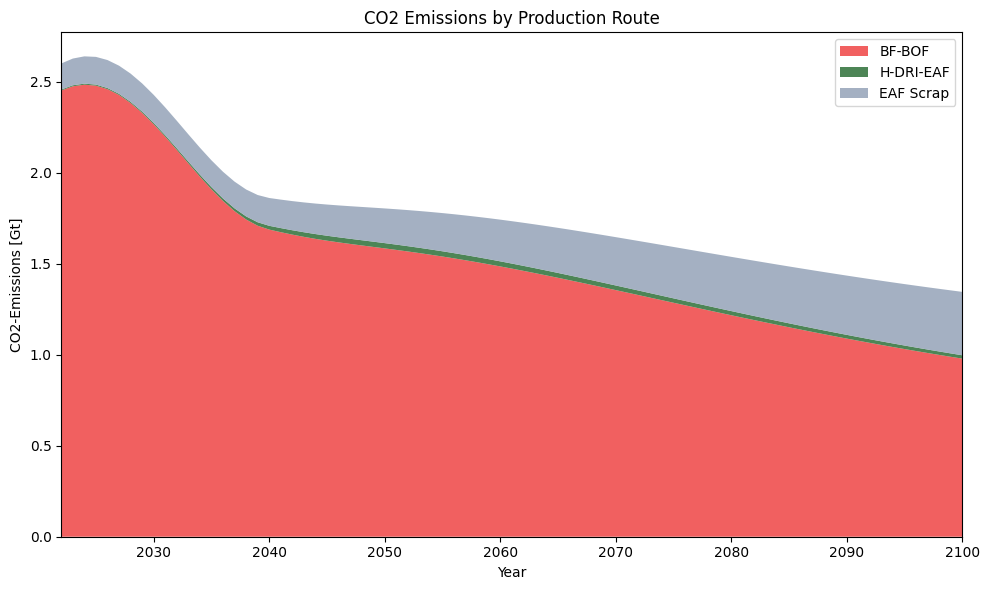

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))

em     = baseline['emissions']
bf_em  = em['BF Emissions']    / 1000
dri_em = em['H-DRI Emissions'] / 1000
eaf_em = em['EAF Emissions']   / 1000

# Apply same IEA 2022 calibration as scenario plot
iea_2022_emissions = 2.6
scale_2022 = iea_2022_emissions / (bf_em[0] + dri_em[0] + eaf_em[0])
t          = np.clip((plot_years - 2022) / (2040 - 2022), 0, 1)
taper      = 0.5 * (1 - np.cos(np.pi * t))
calib      = scale_2022 * (1 - taper) + 1.0 * taper

bf_em  = bf_em  * calib
dri_em = dri_em * calib
eaf_em = eaf_em * calib

ax.stackplot(plot_years, bf_em, dri_em, eaf_em,
             labels=['BF-BOF', 'H-DRI-EAF', 'EAF Scrap'],
             colors=['#ef4444', '#2e7038', '#94a3b8'], alpha=0.85)
ax.set_title('CO2 Emissions by Production Route')
ax.set_xlabel('Year'); ax.set_ylabel('CO2-Emissions [Gt]')
ax.set_ylim(0); ax.set_xlim(2022, 2100)
ax.legend(loc='upper right'); ax.grid(alpha=0)
plt.tight_layout()
plt.show()

# Save plot to vizualization folder
#fig.savefig(viz_folder / 'steel_emissions_by_route.png', dpi=300)

## 7. Hydrogen demand — all scenarios

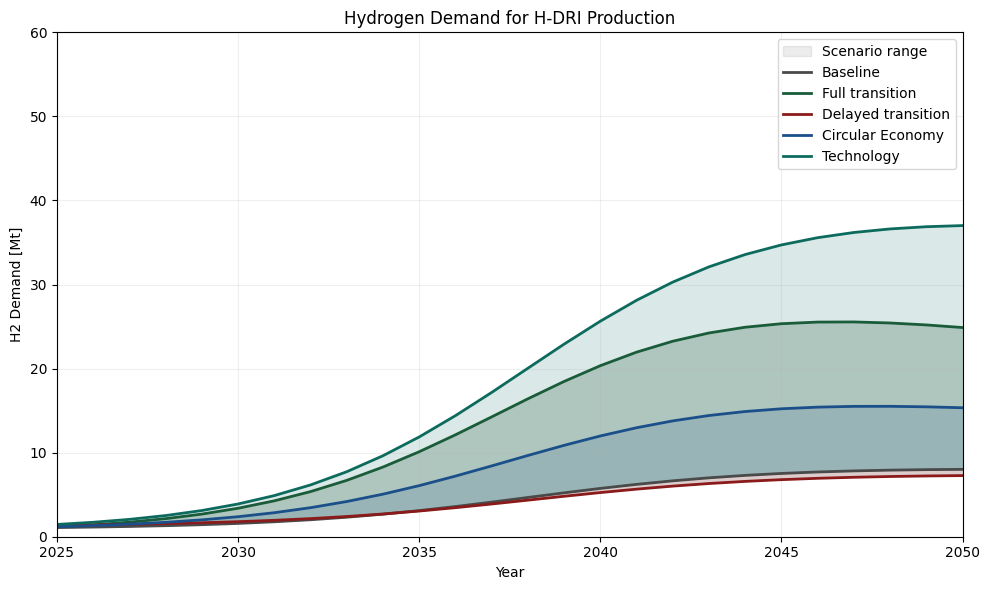

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))

plot_years = baseline['plot_years']
h2 = {name: sc['h2']['H2 Demand (Mt)'] for name, sc in scenarios.items()}

# SSP2 supply
#ax.plot(remind_years, remind_data['SSP2 Current policies']['green_h2'],
#        color='black', linewidth=2.5, linestyle='--',
#        label='Green H$_2$ supply (SSP2 current policies)')

# Fill between worst and best
ax.fill_between(plot_years, h2['Delayed transition'], h2['Full transition'],
                alpha=0.15, color='gray', label='Scenario range')

# Fill between each scenario and baseline
for name, sc in scenarios.items():
    if name == 'Baseline':
        continue
    ax.fill_between(plot_years, h2['Baseline'], h2[name],
                    alpha=0.15, color=sc_colors[name])

# Plot lines on top
for name, sc in scenarios.items():
    ax.plot(plot_years, sc['h2']['H2 Demand (Mt)'],
            color=sc_colors[name], linewidth=2, label=name)

ax.set_title('Hydrogen Demand for H-DRI Production')
ax.set_xlabel('Year'); ax.set_ylabel('H2 Demand [Mt]')
ax.set_ylim(0, 60); ax.set_xlim(2025, 2050)
ax.legend(); ax.grid(True, alpha=0.2)
plt.tight_layout(); plt.show()

# Save plot to vizualization folder
#fig.savefig(viz_folder / 'h2_demand_scenarios.png', dpi=300)

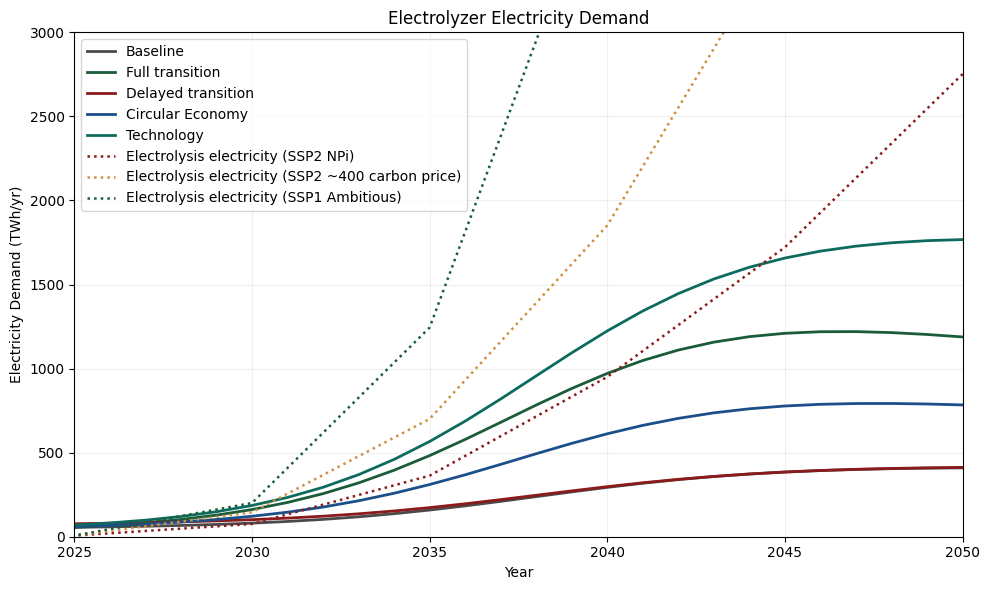

In [38]:
# Blended electrolyzer efficiency per scenario (kWh/kg H2)
blended_efficiency = {
    'Baseline':          0.55*50.0 + 0.35*55.0 + 0.10*43.4,  # 51.1 kWh/kg
    'Full transition':   0.55*47.6 + 0.35*50.2 + 0.10*40.0,  # 47.7 kWh/kg
    'Delayed transition':0.55*56.7 + 0.35*60.5 + 0.10*43.4,  # 57.3 kWh/kg
    'Circular Economy':  0.55*50.0 + 0.35*55.0 + 0.10*43.4,  # 51.1 kWh/kg
    'Technology':        0.55*47.6 + 0.35*50.2 + 0.10*40.0,  # 47.7 kWh/kg
}

# Convert H2 demand → electricity demand
elec = {name: sc['h2']['H2 Demand (Mt)'] * blended_efficiency[name]
        for name, sc in scenarios.items()}

# Then plot exactly as your H2 plot but with elec instead of h2
fig, ax = plt.subplots(figsize=(10, 6))

#ax.fill_between(plot_years, elec['Delayed transition'], elec['Full transition'],
#                alpha=0.15, color='gray', label='Scenario range')

#for name in scenarios:
#    if name == 'Baseline':
#        continue
#    ax.fill_between(plot_years, elec['Baseline'], elec[name],
#                    alpha=0.15, color=sc_colors[name])

for name, sc in scenarios.items():
    ax.plot(plot_years, elec[name],
            color=sc_colors[name], linewidth=2, label=name)

remind_years = remind_data['SSP2 Current policies']['years']

remind_styles = {
    'SSP2 Current policies':  (':', '#8B1A1A', 'Electrolysis electricity (SSP2 NPi)'),
    'SSP2 Carbon price ~400': (':', '#cf9140', 'Electrolysis electricity (SSP2 ~400 carbon price)'),
    'SSP1 Ambitious':         (':', '#1a5c3a', 'Electrolysis electricity (SSP1 Ambitious)'),
}

for ssp_name, (ls, color, label) in remind_styles.items():
    ax.plot(remind_years,
            remind_data[ssp_name]['electrolysis_electricity'],
            color=color, linewidth=1.8, linestyle=ls, label=label)

ax.set_title('Electrolyzer Electricity Demand')
ax.set_xlabel('Year'); ax.set_ylabel('Electricity Demand (TWh/yr)')
ax.set_ylim(0, 3000); ax.set_xlim(2025, 2050)
ax.legend(); ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

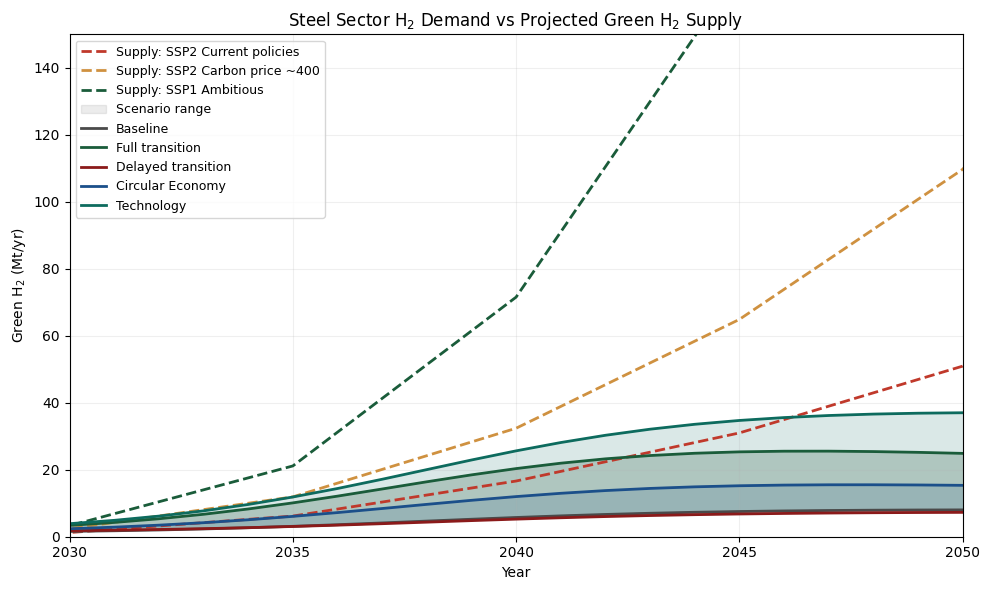

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))

# SSP supply lines
ssp_styles = {
    'SSP2 Current policies':  ('--', '#c0392b'),
    'SSP2 Carbon price ~400': ('--', '#cf9140'),
    'SSP1 Ambitious':         ('--', '#1a5c3a'),
}

for ssp_name, style_color in ssp_styles.items():
    ls, col = style_color
    ax.plot(remind_years, remind_data[ssp_name]['green_h2'],
            color=col, linewidth=2, linestyle=ls, label=f'Supply: {ssp_name}')

# Steel H2 demand scenarios
# Fill between worst and best
ax.fill_between(plot_years, h2['Delayed transition'], h2['Full transition'],
                alpha=0.15, color='gray', label='Scenario range')

# Fill between each scenario and baseline
for name, sc in scenarios.items():
    if name == 'Baseline':
        continue
    ax.fill_between(plot_years, h2['Baseline'], h2[name],
                    alpha=0.15, color=sc_colors[name])

# Plot lines on top
for name, sc in scenarios.items():
    ax.plot(plot_years, sc['h2']['H2 Demand (Mt)'],
            color=sc_colors[name], linewidth=2, label=name)

ax.set_title('Steel Sector H$_2$ Demand vs Projected Green H$_2$ Supply')
ax.set_xlabel('Year')
ax.set_ylabel('Green H$_2$ (Mt/yr)')
ax.set_xlim(2030, 2050)
ax.set_xticks(range(2030, 2051, 5))
ax.set_ylim(0, 150)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

## 8. Electrolyzer capacity — baseline

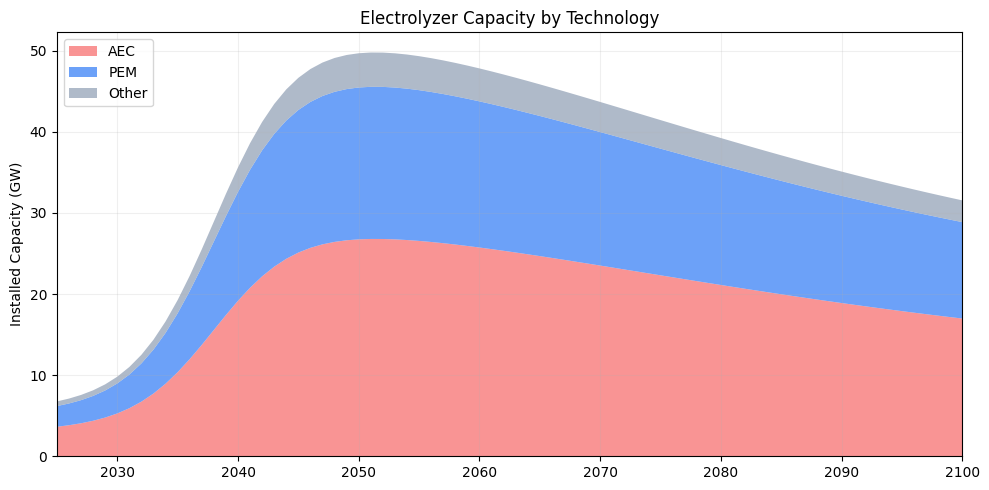

In [12]:
# Plot 1 — Installed capacity
fig, ax = plt.subplots(figsize=(10, 5))
cap = baseline['cap_results']
ax.stackplot(years, cap['AEC'], cap['PEM'], cap['Other'],
             labels=['AEC', 'PEM', 'Other'],
             colors=['#f87171', '#3b82f6', '#94a3b8'], alpha=0.75)
ax.set_ylabel('Installed Capacity (GW)')
ax.set_title('Electrolyzer Capacity by Technology')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.2)
ax.set_xlim(years[3], years[-1])
plt.tight_layout()
plt.show()

# Save plot to vizualization folder
#fig.savefig(viz_folder / 'electrolyzer_capacity_by_technology.png', dpi=300)

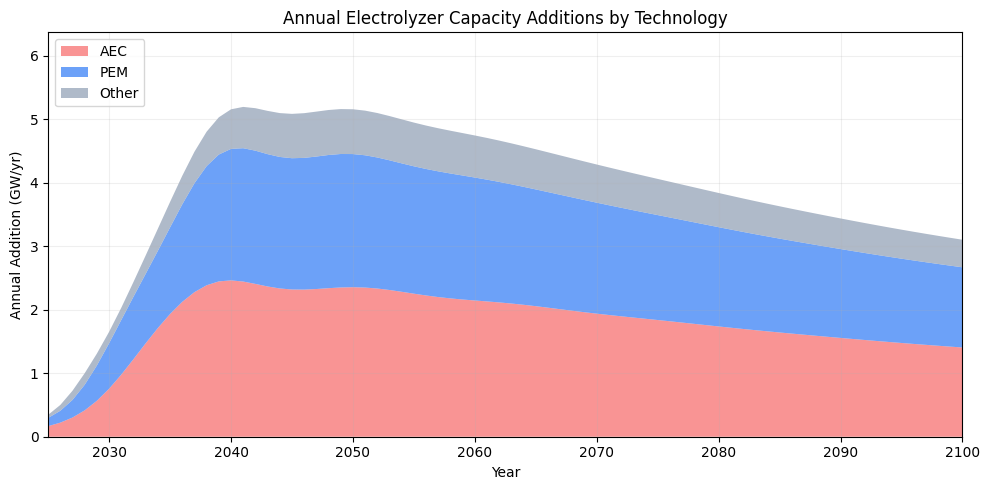

In [13]:
# Plot 2 — Annual additions
fig, ax = plt.subplots(figsize=(10, 5))
dsm = baseline['dsm_elec']
ax.stackplot(years, dsm['i_AEC'], dsm['i_PEM'], dsm['i_Other'],
             labels=['AEC', 'PEM', 'Other'],
             colors=['#f87171', '#3b82f6', '#94a3b8'], alpha=0.75)
ax.set_ylabel('Annual Addition (GW/yr)')
ax.set_xlabel('Year')
ax.set_title('Annual Electrolyzer Capacity Additions by Technology')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.2)
ax.set_xlim(years[3], years[-1])
plt.tight_layout()
plt.show()

# Save plot to vizualization folder
#fig.savefig(viz_folder / 'electrolyzer_additions_by_technology.png', dpi=300)

## 9. Nickel demand — all scenarios

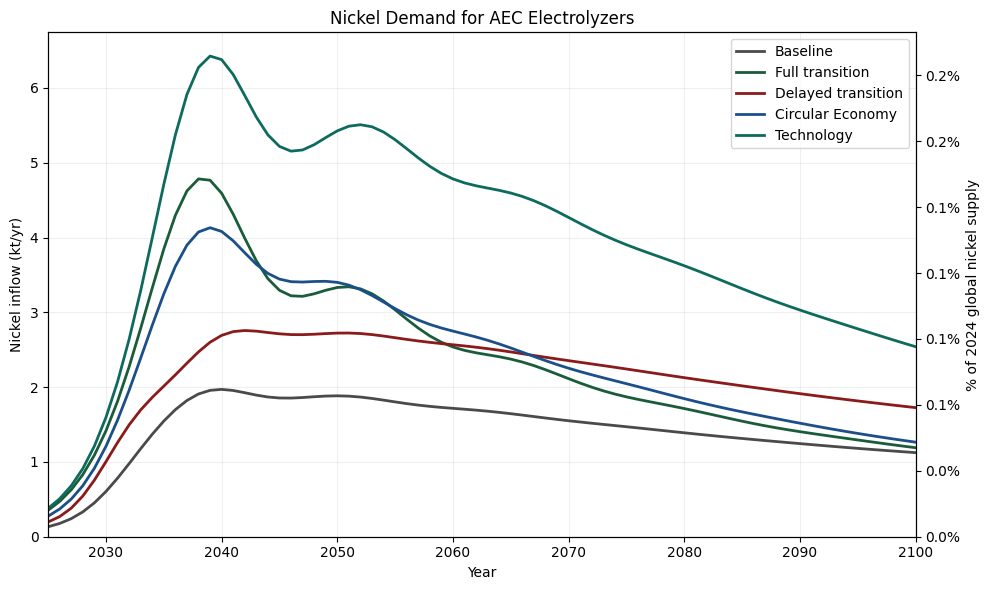

In [14]:
nickel_supply_2024 = 3526  # kt — INSG (2025)

fig, ax = plt.subplots(figsize=(10, 6))

for name, sc in scenarios.items():
    ax.plot(sc['years'], sc['materials']['nickel_inflow'],
            color=sc_colors[name], linewidth=2, label=name)

ax.set_title('Nickel Demand for AEC Electrolyzers')
ax.set_xlabel('Year')
ax.set_ylabel('Nickel inflow (kt/yr)')
ax.set_ylim(0)
ax.set_xlim(2025, 2100)
ax.legend()
ax.grid(True, alpha=0.2)

# Secondary y-axis showing % of 2024 global supply
ax2 = ax.twinx()
ax2.set_ylim(0, ax.get_ylim()[1] / nickel_supply_2024 * 100)
ax2.set_ylabel('% of 2024 global nickel supply')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}%'))

plt.tight_layout()
plt.show()

# Save plot to vizualization folder
#fig.savefig(viz_folder / 'nickel_demand_aec_electrolyzers.png', dpi=300)

## 10. Iridium demand vs supply constraint — all scenarios

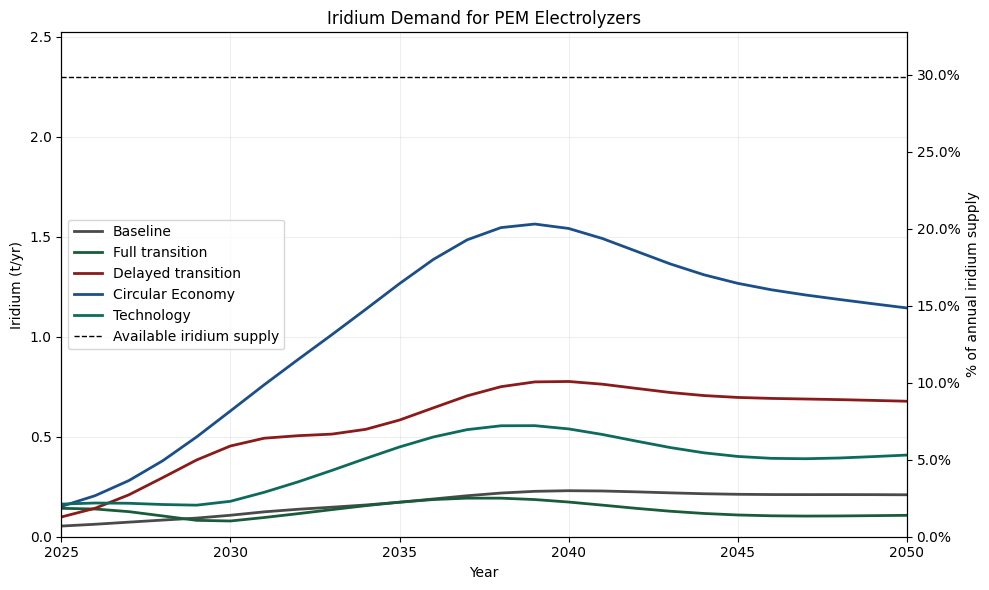

In [15]:
iridium_supply_2024 = 7.7  # t/yr — Johnson Matthey (2024), 248,000 oz converted

iridium_supply = 7.3
other_demand   = 5.0
available      = iridium_supply - other_demand

fig, ax = plt.subplots(figsize=(10, 6))

for name, sc in scenarios.items():
    ir = sc['materials']['iridium_inflow'] * 1000  # kt → t
    ax.plot(sc['years'], ir, color=sc_colors[name], linewidth=2, label=name)

ax.axhline(available, color='black', linewidth=1.0, linestyle='--',
           label='Available iridium supply')

ax.set_title('Iridium Demand for PEM Electrolyzers')
ax.set_xlabel('Year')
ax.set_ylabel('Iridium (t/yr)')
ax.set_ylim(0)
ax.set_xlim(2025, 2050)
ax.legend()
ax.grid(True, alpha=0.2)

# Secondary y-axis showing % of 2024 global supply
ax2 = ax.twinx()
ax2.set_ylim(0, ax.get_ylim()[1] / iridium_supply_2024 * 100)
#ax2.set_ylabel('% of 2024 global iridium supply (7.7 t/yr)')
#ax2.set_ylim(0, ax.get_ylim()[1] / iridium_supply * 100)
ax2.set_ylabel(f'% of annual iridium supply')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}%'))

plt.tight_layout()
plt.show()

# Save plot to vizualization folder
#fig.savefig(viz_folder / 'iridium_demand_pem_electrolyzers.png', dpi=300)

## 11. Pt demand — all scenarios

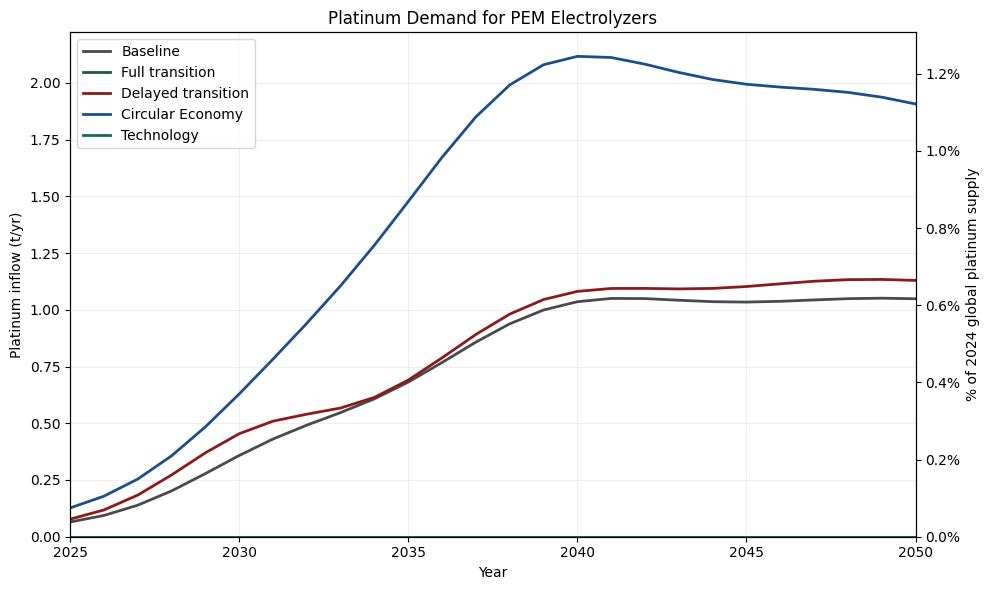

In [16]:
platinum_supply_2024 = 170  # t/yr — USGS (2025)

fig, ax = plt.subplots(figsize=(10, 6))

for name, sc in scenarios.items():
    pt = sc['materials']['platinum_inflow'] * 1000  # kt → t
    ax.plot(sc['years'], pt, color=sc_colors[name], linewidth=2, label=name)

ax.set_title('Platinum Demand for PEM Electrolyzers')
ax.set_xlabel('Year')
ax.set_ylabel('Platinum inflow (t/yr)')
ax.set_ylim(0)
ax.set_xlim(2025, 2050)
ax.legend()
ax.grid(True, alpha=0.2)

# Secondary y-axis showing % of 2024 global supply
ax2 = ax.twinx()
ax2.set_ylim(0, ax.get_ylim()[1] / platinum_supply_2024 * 100)
ax2.set_ylabel('% of 2024 global platinum supply')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}%'))

plt.tight_layout()
plt.show()

# Save plot to vizualization folder
#fig.savefig(viz_folder / 'platinum_demand_pem_electrolyzers.png', dpi=300)

## 12. Summary table at 2050

In [17]:
rows = []
for name, sc in scenarios.items():
    yrs = sc['years']
    idx = np.where(yrs == 2050)[0][0]
    rows.append({
        'Scenario':            name,
        'Stock 2050 (Gt)':     sc['stock_df'][sc['stock_df']['year']==2050]['total_stock'].values[0]/1e9,
        'H-DRI share 2050 (%)':sc['params']['dri_share_2050']*100,
        'CO2 2050 (Mt)':       sc['emissions']['Total Emissions'][idx],
        'H2 2050 (Mt)':        sc['h2']['H2 Demand (Mt)'][idx],
        'Ni 2050 (kt)':        sc['materials']['nickel_inflow'][idx],
        'Ir 2050 (t)':         sc['materials']['iridium_inflow'][idx]*1000,
    })
df_summary = pd.DataFrame(rows).set_index('Scenario').round(2)
print(df_summary.to_string())

                    Stock 2050 (Gt)  H-DRI share 2050 (%)  CO2 2050 (Mt)  H2 2050 (Mt)  Ni 2050 (kt)  Ir 2050 (t)
Scenario                                                                                                         
Baseline                      59.67                  15.0        1803.64          8.01          1.88         0.21
Full transition               46.24                 100.0          32.98         24.88          3.33         0.11
Delayed transition            61.68                  10.0        2134.96          7.27          2.72         0.68
Circular Economy              52.81                  40.0         790.19         15.34          3.40         1.14
Technology                    61.68                  70.0         643.39         37.01          5.43         0.41


In [18]:
rows = []
for name, sc in scenarios.items():
    yrs = sc['years']
    idx = np.where(yrs == 2050)[0][0]
    p   = sc['params']
    rows.append({
        # ── Parameters ────────────────────────────────────────────────────────
        'Scenario':                  name,
        # Steel system
        'L (t/cap)':                 p['L'],
        'Scrap end (%)':             p['scrap_end'] * 100,
        'H-DRI 2050 (%)':            p['dri_share_2050'] * 100,
        'Grid CO2 (g/kWh)':          p['grid_co2'],
        'EAF efficiency (kWh/t)':    p['eaf_efficiency'],
        'H2 conversion (kg/t)':      p['h2_conversion'],
        # Electrolyzer technology
        'AEC share (%)':             p['aec_share'] * 100,
        'PEM share (%)':             p['pem_share'] * 100,
        'AEC lifetime (hrs)':        p['lifetime_AEC'],
        'PEM lifetime (hrs)':        p['lifetime_PEM'],
        'AEC efficiency (kWh/kg)':   p['efficiency_AEC'],
        'PEM efficiency (kWh/kg)':   p['efficiency_PEM'],
        # Critical materials
        'Ni intensity (kg/MW)':      p['nickel_intensity'],
        'Pt intensity (kg/MW)':      p['platinum_intensity'],
        'Ir 2022 (kg/MW)':           p['iridium_intensity_2022'],
        'Ir 2030 (kg/MW)':           p['iridium_intensity_2030'],
        'Ir 2050 (kg/MW)':           p['iridium_intensity_2050'],
        # ── Results at 2050 ───────────────────────────────────────────────────
        'Stock 2050 (Gt)':           sc['stock_df'][sc['stock_df']['year']==2050]['total_stock'].values[0] / 1e9,
        'CO2 2050 (Mt)':             sc['emissions']['Total Emissions'][idx],
        'H2 2050 (Mt)':              sc['h2']['H2 Demand (Mt)'][idx],
        'PEM cap 2050 (GW)':         sc['cap_results']['PEM'][idx],
        'AEC cap 2050 (GW)':         sc['cap_results']['AEC'][idx],
        'Ni 2050 (kt)':              sc['materials']['nickel_inflow'][idx],
        'Pt 2050 (t)':               sc['materials']['platinum_inflow'][idx] * 1000,
        'Ir 2050 (t)':               sc['materials']['iridium_inflow'][idx] * 1000,
    })

df_summary = pd.DataFrame(rows).set_index('Scenario').round(2)

# Display transposed so parameters are rows and scenarios are columns
print(df_summary.T.to_string())

Scenario                 Baseline  Full transition  Delayed transition  Circular Economy  Technology
L (t/cap)                   11.30             6.00               13.00              8.00       13.00
Scrap end (%)               85.00            95.00               85.00             95.00       95.00
H-DRI 2050 (%)              15.00           100.00               10.00             40.00       70.00
Grid CO2 (g/kWh)           400.00             0.00              445.00             80.00       80.00
EAF efficiency (kWh/t)     470.00           310.00              600.00            470.00      310.00
H2 conversion (kg/t)        54.00            54.00               67.00             60.00       54.00
AEC share (%)               55.00            55.00               55.00             55.00       55.00
PEM share (%)               35.00            35.00               35.00             35.00       35.00
AEC lifetime (hrs)       90000.00        101500.00            80000.00          90000.00   

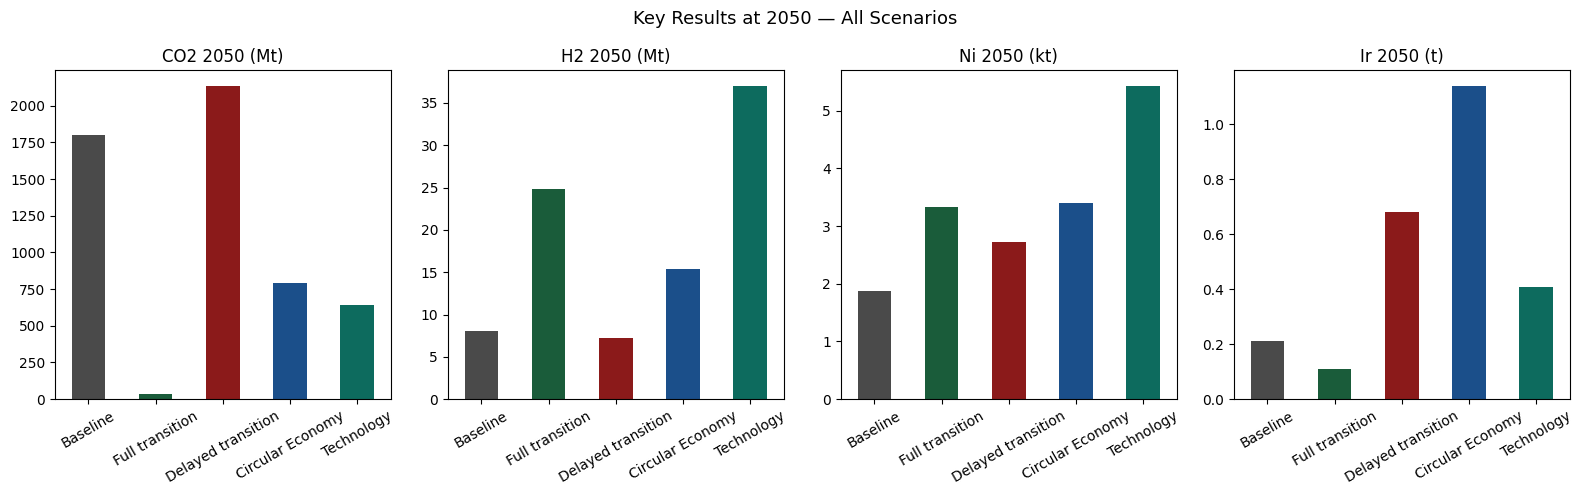

In [19]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
results_cols = ['CO2 2050 (Mt)', 'H2 2050 (Mt)', 'Ni 2050 (kt)', 'Ir 2050 (t)']
colors_list  = list(sc_colors.values())

for ax, col in zip(axes, results_cols):
    df_summary[col].plot(kind='bar', ax=ax, color=colors_list, rot=30)
    ax.set_title(col)
    ax.set_xlabel('')
    ax.grid(True, alpha=0, axis='y')

plt.suptitle('Key Results at 2050 — All Scenarios', fontsize=13)
plt.tight_layout(); plt.show()